In [3]:
import warnings
import pandas as pd
import numpy as np
import re
from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

In [ ]:
# Suppress warnings
warnings.filterwarnings("ignore")

In [5]:
# Step 1: Load Data
data = pd.read_csv('train_data.csv')

In [6]:
data

,HSCODE\tDESC,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,2101111000\tEXTRACTS ESSENCES AND CONCENTRATES...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2101111000\tINSTANT COFFEE MICKEY MOUSE COFFEE...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2101111000\tINSTANT COFFEE STARBUCKS KENYA ESP...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2101111000\tINSTANT COFFEE COFFEE LAUDATIO KAF...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2101111000\tINSTANT COFFEE COFFEE TEA AURORA D...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
12020,2106909099\tOTHER MULTIVITAMIN,GINKGOLD,PRIMADOPHILUS NATURES WAY GINKGOLD EYES 60 TA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12021,2106909099\tOTHER MP CORE CLA 180 SOFTGELS VPX...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12022,2106909099\tOTHER COROMEGA OMEGA-3 FRUIT GUMMI...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12023,2106909099\tOTHER SOLGAR TRIPLE STRENGTH OMEGA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Step 2: Data Cleaning and Preparation
data.columns = data.columns.str.strip()
data[['HSCODE', 'DESC']] = data['HSCODE\tDESC'].str.split('\t', expand=True)
data = data[['HSCODE', 'DESC']].dropna()
data['DESC'] = data['DESC'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', str(x)).lower().strip())
data = data.drop_duplicates()

In [8]:
data

,HSCODE,DESC
0,2101111000,extracts essences and concentrates of coffee c...
1,2101111000,instant coffee mickey mouse coffee time 16g mi...
2,2101111000,instant coffee starbucks kenya espresso capsul...
3,2101111000,instant coffee coffee laudatio kaffeepads clas...
4,2101111000,instant coffee coffee tea aurora de la paz cof...
...,...,...
12020,2106909099,other multivitamin
12021,2106909099,other mp core cla 180 softgels vpx master blas...
12022,2106909099,other coromega omega3 fruit gummies for adults...
12023,2106909099,other solgar triple strength omega3 950 mg 100...


## Step 3: EDA

In [9]:
# Word Frequency Analysis
from collections import Counter
word_counts = Counter(" ".join(data['DESC']).split())

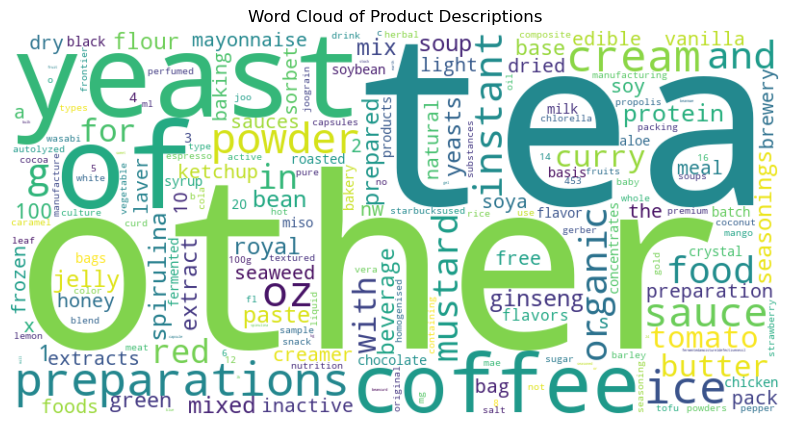

In [10]:
# Visualize Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Product Descriptions')
plt.show()

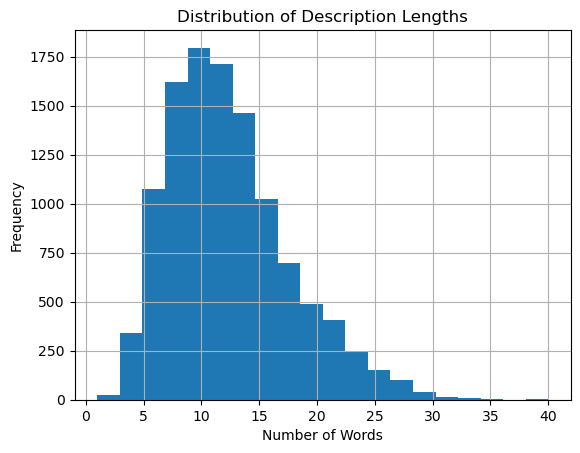

In [11]:
# Text Length Analysis
data['desc_length'] = data['DESC'].apply(lambda x: len(x.split()))
data['desc_length'].hist(bins=20)
plt.title('Distribution of Description Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

## Step 4: Prepare Data for Doc2Vec

In [12]:
# Label the dataset
labeled_data = [TaggedDocument(words=row['DESC'].split(), tags=[str(row['HSCODE'])]) for index, row in data.iterrows()]

# Step 5: Train Doc2Vec Model
doc2vec_model = Doc2Vec(vector_size=100, min_count=2, epochs=100)
doc2vec_model.build_vocab(labeled_data)
doc2vec_model.train(labeled_data, total_examples=doc2vec_model.corpus_count, epochs=doc2vec_model.epochs)

# Step 6: Vectorize Descriptions
data['vectors'] = data['DESC'].apply(lambda x: doc2vec_model.infer_vector(x.split()))
X = np.vstack(data['vectors'])
y = data['HSCODE']

# Step 7: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

## Step 5: Modeling

In [13]:
# Step 8: Train Classifier
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Step 6: Model Evaluation

Model Converged in 70 iterations.


d:\Programs\anaconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Programs\anaconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Programs\anaconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

  2101111000       0.79      0.83      0.81       160
  2101119000       0.84      0.85      0.84       157
  2101121000       0.96      0.89      0.92       157
  2101129010       0.62      0.60      0.61        75
  2101129090       0.70      0.74      0.72       156
  2101201000       0.74      0.78      0.76        94
  2101209011       0.95      0.89      0.92       158
  2101209019       0.78      0.79      0.79       151
  2101209090       0.81      0.63      0.71       174
  2101301000       1.00      0.93      0.97        60
  2101309000       0.72      0.82      0.77       159
  2102101000       0.99      0.94      0.97       154
  2102102000       0.80      0.78      0.79        45
  2102103000       0.96      0.89      0.92       171
  2102104000       0.98      0.90      0.94        71
  2102109000       0.71      0.76      0.73       162
  2102201000       0.88      0.91      0.89       150
  2102202000       0.84    

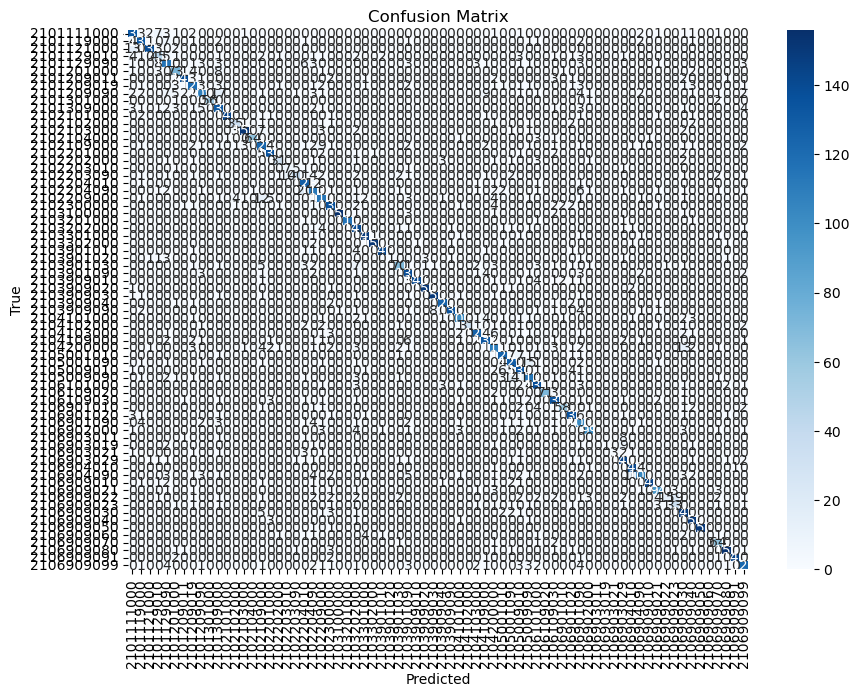

Accuracy: 0.84
F1 Score: 0.84


In [14]:
# Step 9: Evaluate Model
# Check if the model has converged
if hasattr(classifier, 'n_iter_'):
    print(f"Model Converged in {classifier.n_iter_[0]} iterations." if isinstance(classifier.n_iter_, np.ndarray) else 
          f"Model Converged in {classifier.n_iter_} iterations.")

# Predict on the test set
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Accuracy and F1 Score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Accuracy: {accuracy:.2f}')
print(f'F1 Score: {f1:.2f}')

In [ ]:
# Step 9: Define Parameter Grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'solver': ['saga'],  # 'saga' supports l1, l2, and elasticnet
    'l1_ratio': [0.1, 0.5, 0.7, 0.9, None],  # Only relevant for elasticnet
}

# Step 10: Perform Grid Search
grid_search = GridSearchCV(estimator=classifier, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Step 11: Display Optimal Parameters
print("Best Parameters:", grid_search.best_params_)

# Step 12: Evaluate Tuned Model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Step 13: Display Performance Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 80 candidates, totalling 400 fits


d:\Programs\anaconda3\envs\ml\lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


In [ ]:
# Step 10: Test on Unseen Data
def test_model(unseen_data_desc):
    unseen_vector = doc2vec_model.infer_vector(unseen_data_desc.split())
    predicted_hscode = classifier.predict([unseen_vector])[0]
    return predicted_hscode

# Example Test
unseen_desc = "INSTANT COFFEE ILLY INTENSO COFFEE CAPSULE ILLY DEKAFEINE COFFEE CAPSULE"
print(f'Test Description: {unseen_desc}')
print(f'Predicted HSCODE: {test_model(unseen_desc)}')

In [ ]:
# Save Model and Report
import joblib
joblib.dump(doc2vec_model, 'doc2vec_model.pkl')
joblib.dump(classifier, 'classifier_model.pkl')